In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER
import cftime
import datetime
from datetime import date
from matplotlib import pyplot
from matplotlib import font_manager
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
import numpy
import pandas
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import xarray as xr

In [2]:
# Define directories
Diri = '../ExtraTrack_Data/Output_Files_V7/'
Output_Diri = '../RCP_Figs/Analysis_Figs_V7.3.1/'

In [3]:
# Open file
def Open_File(File):
    DF = pandas.read_csv(File)
    DF = DF.drop("Unnamed: 0", axis=1)
    return (DF)

In [4]:
# Open each file
def Files_Open(Scenario, Diri, Subset):
    Data_DF = Open_File(Diri+Scenario+'_Data_'+Subset+'_Output.csv')
    ET_DF = Open_File(Diri+Scenario+'_ET_'+Subset+'_Output.csv')
    Codes_DF = Open_File(Diri+Scenario+'_Codes_Output.csv')
# Edit time format
    Time_Cols = ["ET Begin Time", "ET Complete Time", "Trop Peak Time", "Peak Time", "Genesis Time", "Final Time"]
    for Col in Time_Cols:
        ET_DF[Col] = pandas.to_datetime(ET_DF[Col], errors="coerce")
    Data_DF["Time(Z)"] = pandas.to_datetime(Data_DF["Time(Z)"], errors="coerce")
# Add genesis year and month
    ET_DF["Genesis Year"] = ET_DF["Genesis Time"].dt.year
    ET_DF["Genesis Month"] = ET_DF["Genesis Time"].dt.month
    return (Data_DF, ET_DF, Codes_DF)

In [5]:
# Create bins
def Create_Bins(Min, Max, Bin_Width):
    Bins = numpy.arange(Min, Max+Bin_Width, Bin_Width)
    return (Bins)

In [6]:
# Number of years for each climate scenario
Num_Years = numpy.array([90,93,93])

In [7]:
# Open Dataset A files
Control_Data_A, Control_ET_A, Control_Codes = Files_Open("Control", Diri, 'DatasetA')
RCP45_Data_A, RCP45_ET_A, RCP45_Codes = Files_Open("RCP45", Diri, 'DatasetA')
RCP85_Data_A, RCP85_ET_A, RCP85_Codes = Files_Open("RCP85", Diri, 'DatasetA')

In [8]:
# Open Subset B files
Control_Data, Control_ET, Control_Codes = Files_Open("Control", Diri, 'SubsetB')
RCP45_Data, RCP45_ET, RCP45_Codes = Files_Open("RCP45", Diri, 'SubsetB')
RCP85_Data, RCP85_ET, RCP85_Codes = Files_Open("RCP85", Diri, 'SubsetB')

In [9]:
Control_ET

,Code,Name,Orig Code,Ensemble,Trans Type,Peak Time,Peak SLP,Peak Lon,Peak Lat,Trop Peak Time,...,ET Begin Time,ET Begin SLP,ET Begin Lon,ET Begin Lat,ET Complete Time,ET Complete SLP,ET Complete Lon,ET Complete Lat,Genesis Year,Genesis Month
0,TC190001,Alex,24,A,2,1900-08-31 12:00:00,998.93,-42.40,41.54,1900-08-27 06:00:00,...,1900-08-28 00:00:00,1001.52,-65.34,32.70,1900-09-01 00:00:00,1006.23,-37.00,42.75,1900,8
1,TC190002,Beatrice,26,A,2,1900-09-03 06:00:00,933.33,-53.61,30.15,1900-09-03 06:00:00,...,1900-09-04 06:00:00,943.55,-50.41,35.84,1900-09-10 06:00:00,978.17,-16.15,55.43,1900,8
2,TC190006,Ernest,38,A,2,1900-11-22 18:00:00,991.58,-36.06,34.02,1900-11-22 18:00:00,...,1900-11-24 18:00:00,998.89,-42.28,44.18,1900-11-25 00:00:00,998.75,-42.63,48.24,1900,11
3,TC190103,Kinen,79,A,2,1901-10-13 18:00:00,974.73,-35.58,40.53,1901-10-13 18:00:00,...,1901-10-15 06:00:00,984.17,-21.70,47.01,1901-10-16 00:00:00,999.49,-13.75,44.50,1901,10
4,TC190202,Mario,100,A,2,1902-02-03 18:00:00,973.36,-28.79,33.46,1902-02-03 18:00:00,...,1902-02-06 12:00:00,991.99,-22.84,47.13,1902-02-07 00:00:00,998.08,-21.25,51.41,1902,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290,TC198806,Kelly,1513,C,2,1988-08-24 00:00:00,901.11,-86.52,27.51,1988-08-24 00:00:00,...,1988-08-27 12:00:00,998.18,-85.56,37.72,1988-08-28 06:00:00,996.69,-80.08,40.93,1988,8
291,TC198807,Luca,1514,C,2,1988-08-23 12:00:00,951.47,-71.26,25.86,1988-08-23 12:00:00,...,1988-08-30 06:00:00,983.81,-53.91,48.22,1988-08-30 12:00:00,983.91,-55.38,50.20,1988,8
292,TC198904,Tess,1568,C,2,1989-08-24 00:00:00,950.53,-61.46,36.80,1989-08-24 00:00:00,...,1989-08-24 12:00:00,952.17,-58.80,38.89,1989-08-27 12:00:00,1002.63,-36.27,46.14,1989,8
293,TC198907,Alberto,1572,C,2,1989-09-22 18:00:00,963.58,-56.29,46.85,1989-09-21 12:00:00,...,1989-09-21 18:00:00,995.97,-69.80,38.48,1989-09-23 00:00:00,963.59,-52.56,49.43,1989,9


In [10]:
# Count storms based on genesis month each year
def Count_Months_Per_Year(ET_DF):
    Counts_DF = ET_DF.groupby(["Genesis Year", "Genesis Month"]).size().unstack(fill_value=0)
    Counts_DF["Total"] = Counts_DF.sum(axis=1, numeric_only=True)
    return (Counts_DF)

In [11]:
# Count storms based on genesis month
def Count_Months(ET_DF):
    Counts_DF = Count_Months_Per_Year(ET_DF)
    Sums = numpy.array(Counts_DF.sum())
    return (Sums)

In [12]:
# Create dataframe to store months data
def Months_DF(Control_ET_A, RCP45_ET_A, RCP85_ET_A, Control_ET, RCP45_ET, RCP85_ET):
    Months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Total']
#
# Use function to count number of storm genesis in each month for Dataset A (overall storm count)
    Control_ET_A_Months = Count_Months(Control_ET_A) / 90
    RCP45_ET_A_Months = Count_Months(RCP45_ET_A) / 93
    RCP85_ET_A_Months = Count_Months(RCP85_ET_A) / 93
# Observed Climatology of All North Atlantic TCs
    Climo_A_Months = numpy.array([6,1,1,3,32,113,145,439,709,431,122,24,2026]) / 172
#
# Use function to count number of storm genesis in each month for Subset B (ET Complete Cases)
    Control_ET_B_Months = Count_Months(Control_ET) / 90
    RCP45_ET_B_Months = Count_Months(RCP45_ET) / 93
    RCP85_ET_B_Months = Count_Months(RCP85_ET) / 93
#
# Calculate percentage of ET complete
    Control_ET_Percent = Control_ET_B_Months / Control_ET_A_Months
    RCP45_ET_Percent = RCP45_ET_B_Months / RCP45_ET_A_Months
    RCP85_ET_Percent = RCP85_ET_B_Months / RCP85_ET_A_Months
#
# Create dataframe
    DF = pandas.DataFrame({"Month": Months, "Climo Dataset A": Climo_A_Months, \
    "Control Dataset A": Control_ET_A_Months, "RCP4.5 Dataset A": RCP45_ET_A_Months, "RCP8.5 Dataset A": RCP85_ET_A_Months, \
    "Control Subset B": Control_ET_B_Months, "RCP4.5 Subset B": RCP45_ET_B_Months, "RCP8.5 Subset B": RCP85_ET_B_Months, \
    "Control ET Complete Rate": Control_ET_Percent, "RCP4.5 ET Complete Rate": RCP45_ET_Percent, \
    "RCP8.5 ET Complete Rate": RCP85_ET_Percent})
    DF = DF.round(3)
    return (DF)

In [13]:
# Monthly climatological statistics
Months_Count_DF = Months_DF(Control_ET_A, RCP45_ET_A, RCP85_ET_A, Control_ET, RCP45_ET, RCP85_ET)
Months_Count_DF

,Month,Climo Dataset A,Control Dataset A,RCP4.5 Dataset A,RCP8.5 Dataset A,Control Subset B,RCP4.5 Subset B,RCP8.5 Subset B,Control ET Complete Rate,RCP4.5 ET Complete Rate,RCP8.5 ET Complete Rate
0,Jan,0.035,0.278,0.204,0.204,0.067,0.086,0.086,0.240,0.421,0.421
1,Feb,0.006,0.167,0.215,0.204,0.067,0.086,0.097,0.400,0.400,0.474
2,Mar,0.006,0.256,0.204,0.226,0.111,0.065,0.108,0.435,0.316,0.476
3,Apr,0.017,0.278,0.237,0.151,0.100,0.075,0.075,0.360,0.318,0.500
4,May,0.186,0.200,0.140,0.226,0.078,0.054,0.097,0.389,0.385,0.429
5,Jun,0.657,0.211,0.151,0.204,0.100,0.075,0.129,0.474,0.500,0.632
6,Jul,0.843,0.289,0.108,0.075,0.156,0.032,0.032,0.538,0.300,0.429
7,Aug,2.552,1.178,0.667,0.495,0.644,0.473,0.312,0.547,0.710,0.630
8,Sep,4.122,1.878,0.871,0.753,1.056,0.495,0.473,0.562,0.568,0.629
9,Oct,2.506,1.011,0.785,0.548,0.578,0.462,0.419,0.571,0.589,0.765


In [14]:
# Create function to plot monthly frequency histograms
def Plot_Months(DF, Savefig, Figname):
    Fig = pyplot.figure(figsize=(16,12))
    Months = Create_Bins(1,12,1)
#
# Plot monthly frequency of tropical cyclone genesis climatology VS control
    Axis = Fig.add_subplot(2,2,1)
    Width = 0.25
    pyplot.bar(Months-Width/2, DF["Climo Dataset A"][:12], Width, color='blue', label="Climatology")
    pyplot.bar(Months+Width/2, DF["Control Dataset A"][:12], Width, color='limegreen', label="Control")
    Plot_Month_Formatting(Axis, 0, "Frequency (Per Year)", 0, 5, 0.5, "Monthly Frequency of Tropical Cyclone Genesis")
    pyplot.legend(loc=1, fontsize=15)
#
# Plot monthly frequency of tropical cyclone genesis for each scenario
    Axis = Fig.add_subplot(2,2,2)
    Width = 0.25
    pyplot.bar(Months-Width, DF["Control Dataset A"][:12], Width, color='limegreen', label="Control")
    pyplot.bar(Months, DF["RCP4.5 Dataset A"][:12], Width, color='darkorange', label="RCP4.5")
    pyplot.bar(Months+Width, DF["RCP8.5 Dataset A"][:12], Width, color='red', label="RCP8.5")
    Plot_Month_Formatting(Axis, 1, "Frequency (Per Year)", 0, 2, 0.2, "Monthly Frequency of Tropical Cyclone Genesis")
    pyplot.legend(loc=1, fontsize=15)
#
# Plot monthly frequency of complete ET for each scenario
    Axis = Fig.add_subplot(2,2,3)
    Width = 0.25
    pyplot.bar(Months-Width, DF["Control Subset B"][:12], Width, color='limegreen', label="Control")
    pyplot.bar(Months, DF["RCP4.5 Subset B"][:12], Width, color='darkorange', label="RCP4.5")
    pyplot.bar(Months+Width, DF["RCP8.5 Subset B"][:12], Width, color='red', label="RCP8.5")
    Plot_Month_Formatting(Axis, 2, "Frequency (Per Year)", 0, 1, 0.1, "Monthly Frequency of Complete Extratropical Transitions")
    pyplot.legend(loc=1, fontsize=15)
#
# Plot monthly ET completion rate for each scenario
    Axis = Fig.add_subplot(2,2,4)
    Width = 0.25
    pyplot.bar(Months-Width, DF["Control ET Complete Rate"][:12], Width, color='limegreen', label="Control")
    pyplot.bar(Months, DF["RCP4.5 ET Complete Rate"][:12], Width, color='darkorange', label="RCP4.5")
    pyplot.bar(Months+Width, DF["RCP8.5 ET Complete Rate"][:12], Width, color='red', label="RCP8.5")
    Plot_Month_Formatting(Axis, 3, "ET Completion Rate", 0, 1, 0.1, "Monthly Extratropical Transitions Completion Rate")
    pyplot.legend(loc=1, fontsize=15)
#
# Save Fig
    Fig.tight_layout()
    if Savefig == True:
        Fig.savefig(Output_Diri+Figname, bbox_inches='tight')

In [15]:
# Formatting
def Plot_Month_Formatting(Axis, Plot, y_Label, Dens_Min, Dens_Max, Dens_Width, Title):
# Ticks and lims
    pyplot.xticks(Create_Bins(1,12,1))
    pyplot.xlim(0.5,12.5)
    pyplot.yticks(Create_Bins(Dens_Min, Dens_Max, Dens_Width))
    pyplot.ylim(Dens_Min, Dens_Max)
#
# Labels and title
    pyplot.ylabel(y_Label, fontsize=16)
    pyplot.xlabel("Month", fontsize=16)
    pyplot.title(Title, fontsize=18)
    Letter_Label(Axis, Plot)
#
# Gridlines
    pyplot.grid(linewidth=0.3, color='silver', linestyle='-')

In [16]:
# Letter labels
def Letter_Label(Axis, Plot):
    Fig_Labels = ['(a)','(b)','(c)','(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)']
    Axis.text(0.05, 0.95, str(Fig_Labels[int(Plot)]), ha='center', va='center', \
    transform=Axis.transAxes, fontdict={'size':24},color='black')

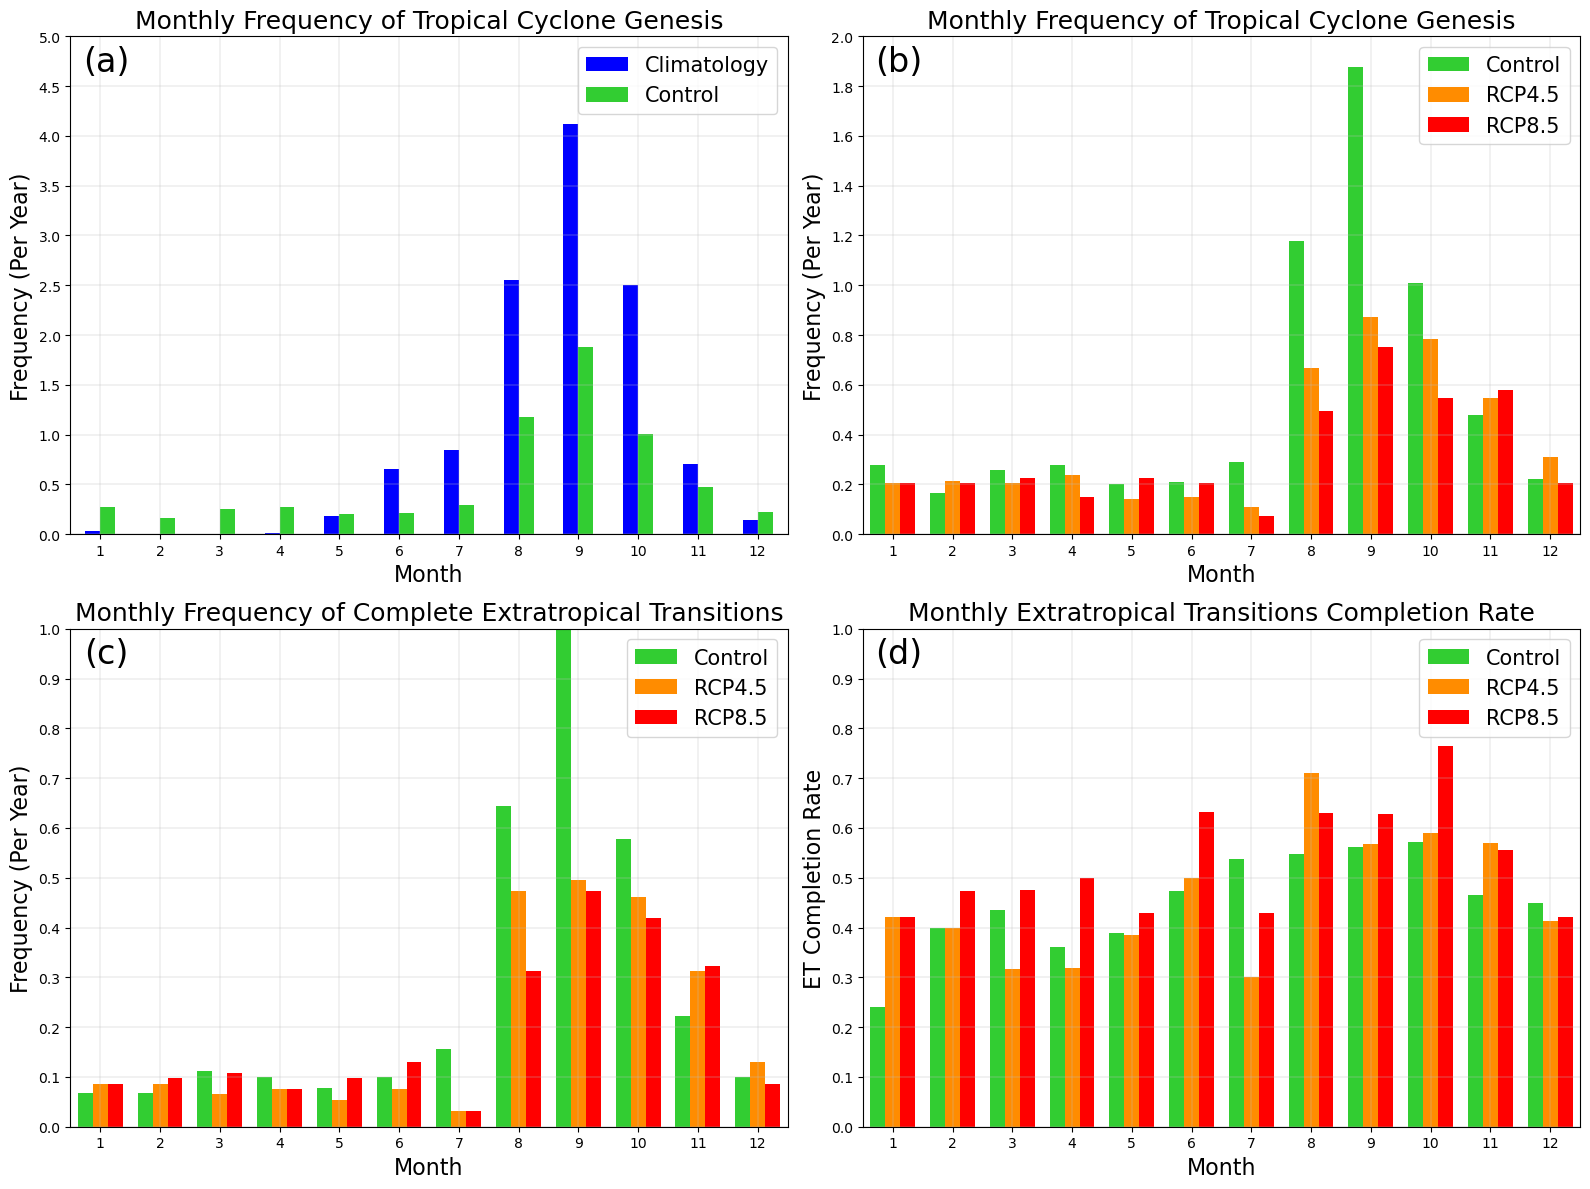

In [17]:
# Plot monthly frequency histogram
Plot_Months(Months_Count_DF, True, 'Months_Histogram.png')

In [18]:
# Calculate statistical significance of differences in monthly frequencies using t-test
def Monthly_T_Test(Control_ET, RCP_ET):
    Control_Months = Count_Months_Per_Year(Control_ET)
    RCP_Months = Count_Months_Per_Year(RCP_ET)
    P_Vals = numpy.zeros(13)
    for i in range(12):
        P_Vals[i] = stats.ttest_ind(Control_Months[i+1], RCP_Months[i+1], equal_var=False)[1]
    P_Vals[12] = stats.ttest_ind(Control_Months["Total"], RCP_Months["Total"], equal_var=False)[1]
    return (P_Vals)

In [19]:
# Calculate statistical significance of differences in ET completion rate using z-test
def Monthly_Z_Test(Months_Count_DF, RCP):
    Control_A = Months_Count_DF["Control Dataset A"] * 90
    Control_B = Months_Count_DF["Control Subset B"] * 90
    RCP_A = Months_Count_DF[RCP+" Dataset A"] * 90
    RCP_B = Months_Count_DF[RCP+" Subset B"] * 90
    P_Vals = numpy.zeros(13)
    for i in range(13):
        Vals_A = [Control_A[i], RCP_A[i]]
        Vals_B = [Control_B[i], RCP_B[i]]
        P_Vals[i] = proportions_ztest(Vals_B, Vals_A)[1]
    return (P_Vals)

In [20]:
# Apply statistical significance functions and save to dataframe
Months_Signif_DF = pandas.DataFrame({"Month": Months_Count_DF["Month"]})
Months_Signif_DF["P Values RCP4.5 Dataset A"] = Monthly_T_Test(Control_ET_A, RCP45_ET_A)
Months_Signif_DF["P Values RCP8.5 Dataset A"] = Monthly_T_Test(Control_ET_A, RCP85_ET_A)
Months_Signif_DF["P Values RCP4.5 Subset B"] = Monthly_T_Test(Control_ET, RCP45_ET)
Months_Signif_DF["P Values RCP8.5 Subset B"] = Monthly_T_Test(Control_ET, RCP85_ET)
Months_Signif_DF["P Values RCP4.5 ET Complete Rate"] = Monthly_Z_Test(Months_Count_DF, "RCP4.5")
Months_Signif_DF["P Values RCP8.5 ET Complete Rate"] = Monthly_Z_Test(Months_Count_DF, "RCP8.5")
Months_Signif_DF = Months_Signif_DF.round(3)
Months_Signif_DF

,Month,P Values RCP4.5 Dataset A,P Values RCP8.5 Dataset A,P Values RCP4.5 Subset B,P Values RCP8.5 Subset B,P Values RCP4.5 ET Complete Rate,P Values RCP8.5 ET Complete Rate
0,Jan,0.329,0.364,0.535,0.492,0.207,0.207
1,Feb,0.445,0.528,0.538,0.358,0.994,0.667
2,Mar,0.524,0.763,0.412,0.830,0.450,0.770
3,Apr,0.611,0.093,0.706,0.760,0.757,0.408
4,May,0.361,0.631,0.623,0.474,0.981,0.805
5,Jun,0.322,1.000,0.689,0.357,0.898,0.330
6,Jul,0.009,0.002,0.027,0.029,0.195,0.600
7,Aug,0.001,0.000,0.270,0.009,0.040,0.344
8,Sep,0.000,0.000,0.000,0.000,0.929,0.353
9,Oct,0.121,0.000,0.502,0.300,0.830,0.023


In [21]:
# Output DF to csv file
def Output_File(DF, File_Name):
    DF.to_csv(Output_Diri+File_Name)

In [22]:
# Output monthly climatological statistics table
Output_File(Months_Signif_DF, 'Months_Signif.csv')